In [1]:
import sys
sys.path.append('./')
sys.path.append('/Users/ASUS/Documents/GitHub/retrospective_t2e_analysis/auton-survival/')

import pandas as pd
import numpy as np

import torch
from tqdm import tqdm 
from examples.cmhe_demo_utils import * 
from auton_survival import reporting
import matplotlib.pyplot as plt
from metrics import treatment_effect
from matplotlib.pyplot import figure

c:\Users\ASUS\anaconda3\envs\Pandas\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from datasets_retrospective import load_accord_dataset
outcomes, features, intervention, cat_feats, num_feats = load_accord_dataset(location='datasets/ACCORD/', outcome='', intervention='BP')

No Features Specified!! using default baseline features.
(10251, 5)
(10205, 3)
(10251, 18)
(10197, 5)
(10240, 9)


c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, col] = df[col].values.astype(str)
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:754: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outcomes['event'] = 1-outcomes['event']
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_re

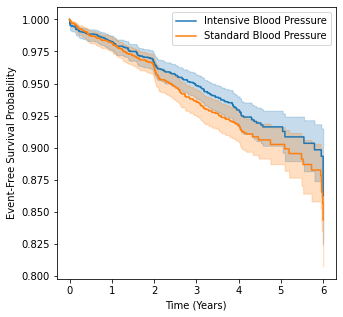

In [5]:
# Let's plot the survival curves in the original paper
figure(figsize=(5,5))
ax_1 = reporting.plot_kaplanmeier(outcomes, intervention)
h, l = ax_1.get_legend_handles_labels()
plt.xlabel('Time (Years)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Intensive Blood Pressure', 'Standard Blood Pressure'], loc="upper right")
plt.show()
pass

In [6]:
# Preprocess feature data
from preprocessing import Preprocessor
features_prep = Preprocessor().fit_transform(data=features[cat_feats+num_feats], cat_feats=cat_feats, num_feats=num_feats)

In [7]:
# Hyper-parameters to train model
k = 1 # number of underlying base survival phenotypes
g = 2 # number of underlying treatment effect phenotypes.
layers = [] # number of neurons in each hidden layer.

random_seed = 3
iters = 100 # number of training epochs
learning_rate = 0.001
batch_size = 256 
# vsize = 0.15 # size of the validation split
patience = 5
optimizer = "Adam"
gate_l2_penalty = 1e-3

In [8]:
from models.cmhe import DeepCoxMixturesHeterogenousEffects

torch.manual_seed(random_seed)
np.random.seed(random_seed)

# Instantiate the CMHE model
model = DeepCoxMixturesHeterogenousEffects(random_seed=10, k=k, g=g, layers=layers, gate_l2_penalty=gate_l2_penalty)

model = model.fit(features_prep, outcomes.time, outcomes.event, intervention=='Intensive Blood Pressure', val_data=None, iters=iters, 
                  learning_rate=learning_rate, batch_size=batch_size, 
                  optimizer=optimizer, patience=patience)

100%|██████████| 100/100 [00:19<00:00,  5.04it/s]


In [9]:
zeta_probs = model.predict_latent_phi(features_prep)
zeta =  np.argmax(zeta_probs, axis=1)

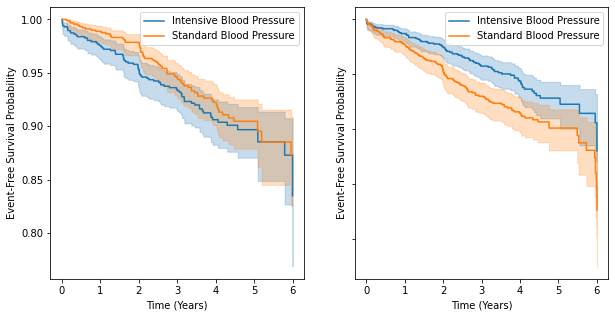

In [10]:
fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(10, 5))
reporting.plot_kaplanmeier(outcomes[zeta == 0], intervention[zeta == 0], ax=ax1)
reporting.plot_kaplanmeier(outcomes[zeta == 1], intervention[zeta == 1], ax=ax2)
for ax in fig.get_axes():
    ax.label_outer()
    h, l = ax.get_legend_handles_labels()
    ax.set_xlabel('Time (Years)')
    ax.set_ylabel('Event-Free Survival Probability')
    ax.legend([h[0], h[1]], ['Intensive Blood Pressure', 'Standard Blood Pressure'], loc="upper right")
plt.show()

In [11]:
hr = treatment_effect('hazard_ratio', outcomes, intervention=='Intensive Blood Pressure', n_bootstrap=100)
CI = np.quantile(hr, [0.025, 0.975])
print(CI)
print(sum(hr)/len(hr))

c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\metrics.py:107: UserWarning: WARNING: You are computing Hazard Ratios.
 Make sure you have tested the PH Assumptions.
  warnings.warn("WARNING: You are computing Hazard Ratios.\n Make sure you have tested the PH Assumptions.")


Bootstrapping...  100  number of times. This may take a while. Please be Patient...
[0.69480101 1.053927  ]
0.8474480964355408


In [12]:
hr_zeta0 = treatment_effect('hazard_ratio', outcomes[zeta == 0], intervention[zeta == 0] == 'Intensive Blood Pressure', n_bootstrap=100)
CI_zeta0 = np.quantile(hr_zeta0, [0.025, 0.975])
print(CI_zeta0)
print(sum(hr_zeta0)/len(hr_zeta0))

c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\metrics.py:107: UserWarning: WARNING: You are computing Hazard Ratios.
 Make sure you have tested the PH Assumptions.
  warnings.warn("WARNING: You are computing Hazard Ratios.\n Make sure you have tested the PH Assumptions.")


Bootstrapping...  100  number of times. This may take a while. Please be Patient...
[0.9005794  1.57432965]
1.1974235528248018


In [13]:
hr_zeta1 = treatment_effect('hazard_ratio', outcomes[zeta == 1], intervention[zeta == 1] == 'Intensive Blood Pressure', n_bootstrap=100)
CI_zeta1 = np.quantile(hr_zeta1, [0.025, 0.975])
print(CI_zeta1)
print(sum(hr_zeta1)/len(hr_zeta1))

c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\metrics.py:107: UserWarning: WARNING: You are computing Hazard Ratios.
 Make sure you have tested the PH Assumptions.
  warnings.warn("WARNING: You are computing Hazard Ratios.\n Make sure you have tested the PH Assumptions.")


Bootstrapping...  100  number of times. This may take a while. Please be Patient...
[0.505262   0.91140222]
0.6815629334600977


In [14]:
# Get the numerical features
cols_to_use2 = features.columns.difference(features_prep.columns)
feat_num = features.loc[:, ~features.columns.isin(cols_to_use2)]
feat_num

,Baseline_Potassium,Baseline_Creatine_Phosphokinase,Baseline_Fasting_Plasma_Glucose,Baseline_Age,Baseline_Estimated_Glomerular_Filtration_Rate,Baseline_Total_Cholesterol,Baseline_HDL_Cholesterol,Baseline_Urine_albumin,Baseline_Heart_Rate,Baseline_Very_low_density_lipoprotein,Baseline_Serum_creatinine,Baseline_Triglycerides,Baseline_LDL_Cholesterol,Baseline_Urine_creatinine,Baseline_Alanine_Transaminase,Baseline_Seated_Systolic_Blood_Pressure,Baseline_Urine_albumin/creatinine_ratio,Baseline_Seated_Diastolic_Blood_Pressure
MaskID,,,,,,,,,,,,,,,,,,
109144.0,5.09,72.0,153.0,76.7,99.7,152.0,64.0,0.22,66.0,11.0,0.8,53.0,77.0,0.305,12.0,115.0,NaN,57.0
102274.0,5.05,129.0,153.0,55.6,68.9,162.0,50.0,0.99,64.0,24.0,0.9,119.0,88.0,2.055,26.0,118.0,0.5,67.0
103668.0,4.19,103.0,188.0,56.0,61.0,167.0,54.0,0.60,49.0,20.0,1.0,101.0,93.0,0.565,27.0,133.0,1.1,56.0
103029.0,4.59,156.0,100.0,64.5,79.8,147.0,41.0,13.20,56.0,16.0,1.0,78.0,90.0,2.189,37.0,150.0,6.0,85.0
105960.0,4.84,102.0,309.0,57.6,92.2,175.0,57.0,0.50,64.0,10.0,0.9,51.0,108.0,0.880,38.0,123.0,0.6,69.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102460.0,4.64,92.0,234.0,58.3,78.2,204.0,44.0,1.55,62.0,50.0,0.8,248.0,110.0,1.637,28.0,140.0,0.9,76.0
107440.0,4.44,151.0,125.0,55.8,82.2,201.0,35.0,1.34,93.0,40.0,1.0,200.0,126.0,1.115,46.0,106.0,1.2,63.0
103850.0,3.85,217.0,241.0,60.8,77.6,215.0,67.0,0.23,70.0,12.0,0.8,62.0,136.0,0.153,48.0,156.0,NaN,70.0


In [15]:
# Get the categorical features
cols_to_use = features_prep.columns.difference(features.columns)
feat_cat = features_prep[cols_to_use]
feat_cat

,Baseline_BMI_>32_Yes,Baseline_History_Albuminuria_Not Available,Baseline_History_Albuminuria_Yes,Baseline_History_Angina_Yes,Baseline_History_Cardiovascular_Disease_Yes,Baseline_History_Coronary_Artery_Bypass_Graft_Yes,Baseline_History_Left_Ventricular_Hypertrophy_Not Available,Baseline_History_Left_Ventricular_Hypertrophy_Yes,Baseline_History_Myocardial_Infarction_Yes,Baseline_History_Percutaneous_Coronary_Intervention_Yes,...,Baseline_Low_Ankle_Brachial_Index_Not Available,Baseline_Low_Ankle_Brachial_Index_Yes,Baseline_Not_On_Blood_Pressure_Medication_Yes,Baseline_On_Blood_Pressure_Medication_Yes,Baseline_Prior_revascularization_Yes,Baseline_Smoke_status_Yes,Race_Hispanic,Race_Other,Race_White,Sex_Male
MaskID,,,,,,,,,,,,,,,,,,,,,
109144.0,0,0,0,0,1,1,0,0,0,0,...,0,0,1,0,0,0,0,0,1,1
102274.0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
103668.0,0,0,1,0,0,0,1,0,0,0,...,1,0,0,1,0,1,0,0,1,0
103029.0,0,0,1,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,1
105960.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102460.0,1,1,0,1,1,0,1,0,0,0,...,1,0,0,1,0,0,0,0,1,0
107440.0,1,0,1,1,1,0,0,0,0,1,...,0,1,0,1,0,0,0,0,1,1
103850.0,0,0,0,0,0,0,1,0,0,0,...,1,0,0,1,0,0,0,1,0,0


In [16]:
# Get the features to train Decision Tree Classifier
features_dt = pd.merge(feat_cat, feat_num, left_index=True, right_index=True, how='inner')
features_dt

,Baseline_BMI_>32_Yes,Baseline_History_Albuminuria_Not Available,Baseline_History_Albuminuria_Yes,Baseline_History_Angina_Yes,Baseline_History_Cardiovascular_Disease_Yes,Baseline_History_Coronary_Artery_Bypass_Graft_Yes,Baseline_History_Left_Ventricular_Hypertrophy_Not Available,Baseline_History_Left_Ventricular_Hypertrophy_Yes,Baseline_History_Myocardial_Infarction_Yes,Baseline_History_Percutaneous_Coronary_Intervention_Yes,...,Baseline_Heart_Rate,Baseline_Very_low_density_lipoprotein,Baseline_Serum_creatinine,Baseline_Triglycerides,Baseline_LDL_Cholesterol,Baseline_Urine_creatinine,Baseline_Alanine_Transaminase,Baseline_Seated_Systolic_Blood_Pressure,Baseline_Urine_albumin/creatinine_ratio,Baseline_Seated_Diastolic_Blood_Pressure
MaskID,,,,,,,,,,,,,,,,,,,,,
109144.0,0,0,0,0,1,1,0,0,0,0,...,66.0,11.0,0.8,53.0,77.0,0.305,12.0,115.0,NaN,57.0
102274.0,1,0,0,0,0,0,0,0,0,0,...,64.0,24.0,0.9,119.0,88.0,2.055,26.0,118.0,0.5,67.0
103668.0,0,0,1,0,0,0,1,0,0,0,...,49.0,20.0,1.0,101.0,93.0,0.565,27.0,133.0,1.1,56.0
103029.0,0,0,1,0,0,0,0,0,0,0,...,56.0,16.0,1.0,78.0,90.0,2.189,37.0,150.0,6.0,85.0
105960.0,0,0,0,0,0,0,0,0,0,0,...,64.0,10.0,0.9,51.0,108.0,0.880,38.0,123.0,0.6,69.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102460.0,1,1,0,1,1,0,1,0,0,0,...,62.0,50.0,0.8,248.0,110.0,1.637,28.0,140.0,0.9,76.0
107440.0,1,0,1,1,1,0,0,0,0,1,...,93.0,40.0,1.0,200.0,126.0,1.115,46.0,106.0,1.2,63.0
103850.0,0,0,0,0,0,0,1,0,0,0,...,70.0,12.0,0.8,62.0,136.0,0.153,48.0,156.0,NaN,70.0


In [17]:
from sklearn.model_selection import train_test_split

# Split the SPRINT data into training, validation, and test data
x_train, x_test, y_train, y_test = train_test_split(features_dt, outcomes, test_size=0.3, random_state=1, 
                                          stratify = outcomes.event + 2*(intervention=='Intensive Blood Pressure'))

print(f'Number of training data points: {len(x_train)}')
print(f'Number of test data points: {len(x_test)}')

Number of training data points: 3180
Number of test data points: 1364


In [18]:
# Get the Zeta for Train data
idxs = x_train.dropna(axis=0).index.values.astype(int)
f_idxs = features_prep.index.values.astype(int)
mask = np.in1d(f_idxs, idxs)

# Get the Zeta for Test data
idxs2 = x_test.dropna(axis=0).index.values.astype(int)
f_idxs2 = features_prep.index.values.astype(int)
mask2 = np.in1d(f_idxs2, idxs2)

In [19]:
from sklearn import tree # Import the decision tree namespace
from sklearn.metrics import plot_confusion_matrix # Generate a confusion matrix

In [24]:
# Create and fit the model using entropy separation and a maximum depth
# Drop NaNs because the feature columns not preprocessed i.e. 
# Numerical features have NaNs 
dt_model = tree.DecisionTreeClassifier(criterion='entropy', max_depth=4)
dt_model.fit(x_train.dropna(axis=0), zeta[mask])

DecisionTreeClassifier(criterion='entropy', max_depth=4)

c:\Users\ASUS\anaconda3\envs\Pandas\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


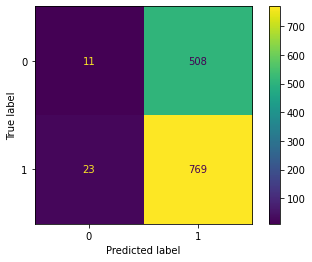

In [25]:
# Plot the confusion matrix
plot_confusion_matrix(dt_model, x_test.dropna(axis = 0), zeta[mask2], values_format='d', labels=[0, 1])

In [26]:
# Get the accuracy of test and train data
from sklearn.model_selection import cross_validate
scoring = ['accuracy','precision', 'recall', 'f1']
scores = cross_validate(dt_model, x_train.dropna(axis = 0), zeta[mask], scoring=scoring, return_train_score=True, cv=5)
results = pd.DataFrame(scores)
results.mean()

fit_time           0.019289
score_time         0.006017
test_accuracy      0.605950
train_accuracy     0.619339
test_precision     0.615650
train_precision    0.623405
test_recall        0.955375
train_recall       0.967049
test_f1            0.747396
train_f1           0.756860
dtype: float64

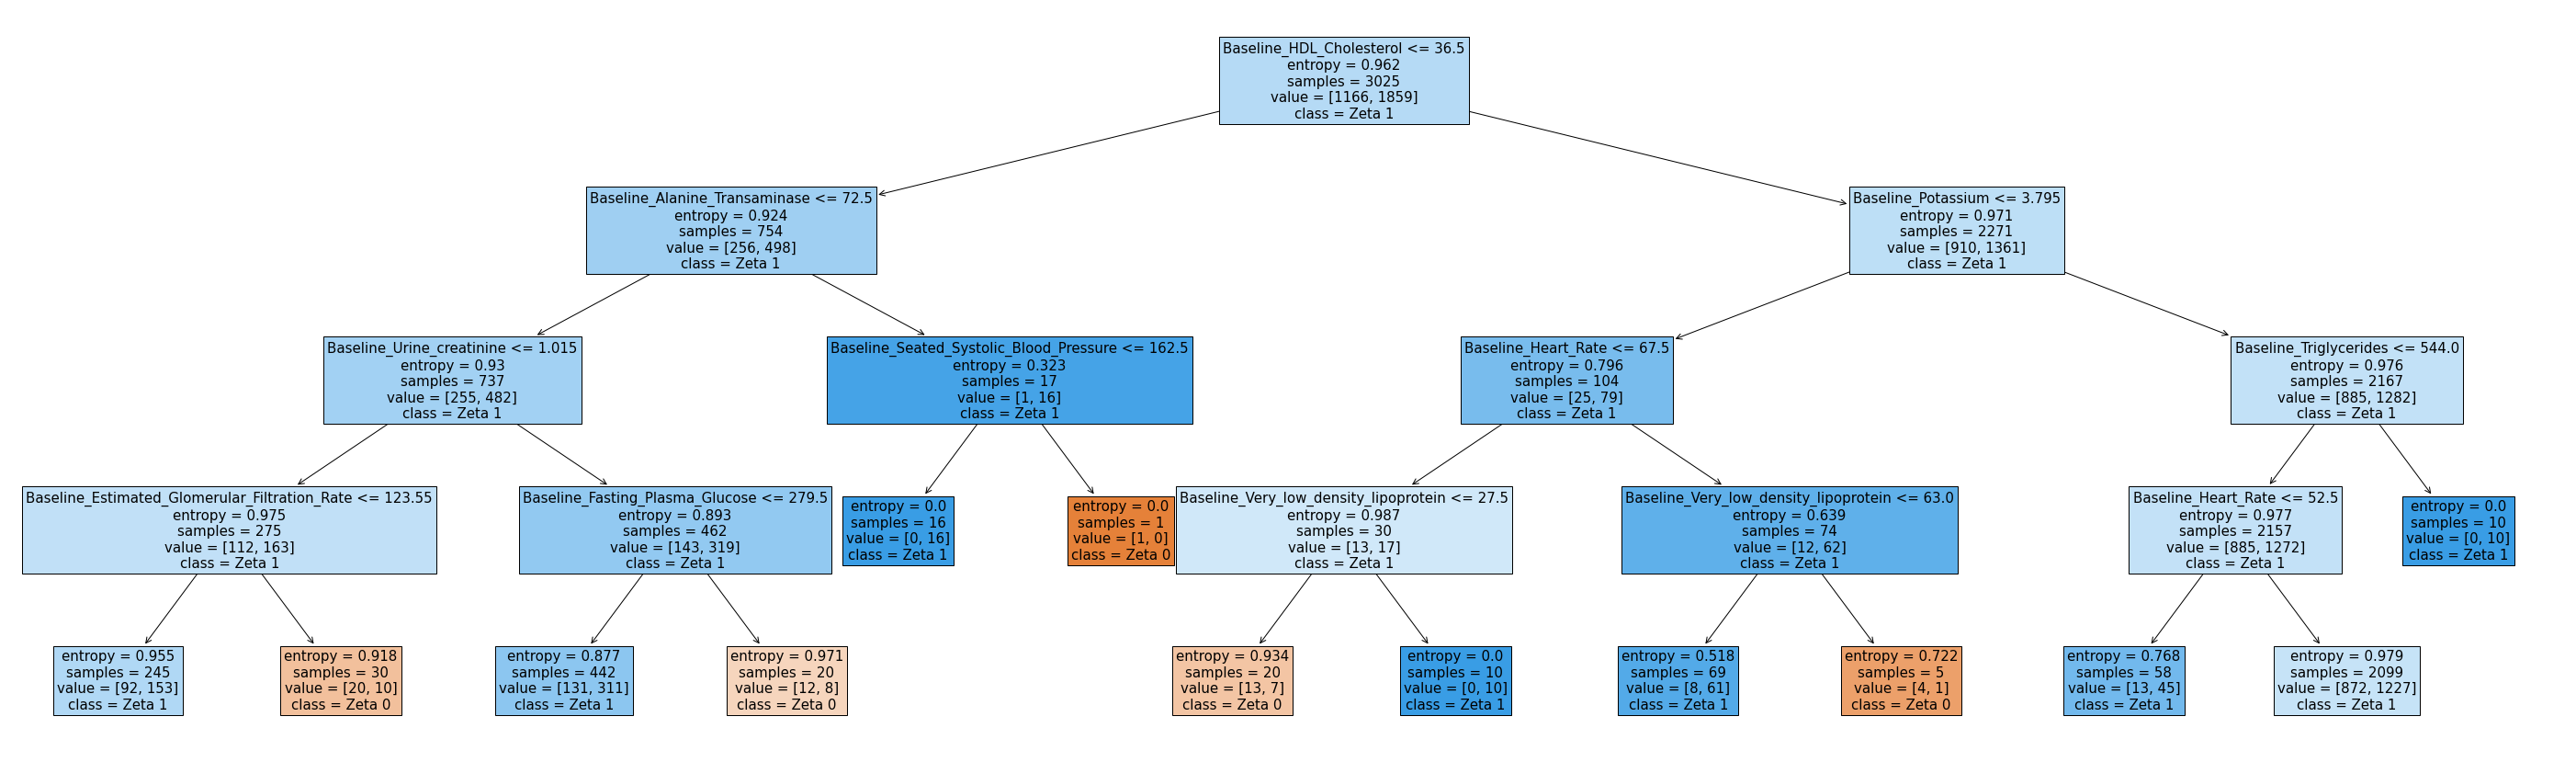

In [34]:
# Let's check out the tree
plt.figure(figsize=(50,15))
tree.plot_tree(dt_model, feature_names=features_dt.columns, class_names=['Zeta 0', 'Zeta 1'], fontsize=15, filled=True)
plt.show()